# TP de Synthèse : Machine Learning avec Python

L'objectif de ce TP est de faire une synthèse de toutes les notions que vous avez vu sur l'ensemble du cours IA & Python.

À partir d'un jeu de donnée imposé, vous allez devoir proposer une analyse détaillée, et produire des modèles prédictifs avec les meilleures performances possibles.

## À votre disposition :
- Un fichier `Hotel_Booking.csv` contenant les données à analyser, avec pour chaque donnée la valeur de la classe à prédire
- Un fichier `Data_Test.csv` de test, comprenant des données sans la valeur de la classe
- Ce notebook, contenant toutes vos instructions, ainsi qu'une description du _Dataset_

## Méthode de travail :
Ce travail peut-être effectué seul, ou en groupe de 2 personnes.

## Rendus attendus :
- Un notebook comprenant votre analyse détaillé du _Dataset_, et la construction de vos modèles prédictifs
- Un fichier CSV, avec sur chaque ligne votre prédiction de classe pour la ligne correspondante dans le fichier de test (`Donnees_Test.csv`).<br/>Ce fichier doit être nommé `NOM_Prénom.csv` ou `NOM1_NOM2.csv` (si binôme) ou `NOM_Prénom_vX.csv` (si plusieurs versions), et ne contient qu'une info par ligne : soit `Canceled`, soit `Not_Canceled`.

## Évaluation :
- Lorsque tous les groupes auront rendu leur fichier csv, le formatteur fera tourner un script, pour identifier le groupe ayant produit le modèle avec le meilleur résultat sur le jeu de test.
- Vous devrez fournir vos notebook à un autre groupe de la classe, et relire le notebook d'un autre groupe, pour lui faire un retour sur la qualité de l'analyse de ses données.

## Description des données

Les données à votre disposition décrivent les informations des clients de réservations de chambres d'hôtels.

L'objectif est de détermine, pour chaque client, s'il risque d'annuler sa réservation.

Vous avez à votre disposition les attributs suivants :

- `Booking_ID`: identifiant unique de chaque réservation
- `no_of_adults`: nombre d'adultes dans la réservation
- `no_of_children`: nombre d'enfants dans la réservation
- `no_of_weekend_nights`: nombre de nuits en weekend (samedi ou dimanche) incluses dans la réservation
- `no_of_week_nights`: nombre de nuits de semaine (lundi au vendredi) incluses dans la réservation
- `type_of_meal_plan`: choix de formule repas
- `required_car_parking_space` : indique une réservation de place de parking (0 : non, 1 : oui)
- `room_type_reserved`: type de chambre réservé
- `lead_time` : nombre de jours entre la date de réservation et la date d'arrivée
- `arrival_year` : année de la date d'arrivée
- `arrival_month`: mois de la date d'arrivée
- `arrival_date`: jour de la date d'arrivée
- `market_segment_type`: désignation du segment marketing
- `repeated_guest` : indique s'il s'agit d'un client fréquent (0 : non, 1 : oui)
- `no_of_previous_cancellations` : nombre d'annulation déjà faite par ce client sur d'autres réservations
- `no_of_previous_bookings_not_canceled`: nombre de réservations déjà faites sans annulations
- `avg_price_per_room`: prix moyen journalier de la réservation (en euros)
- `no_of_special_requests`: nombre total des requêtes spécifiques du client (étage, vue, ...)
- `booking_status` : indique si la réservation a été annulée ou non (=classe à prédire !)

## Les questions auxquelles vous devez répondre

Nous vous proposons ci-après une liste de questions à vous poser.
Il ne s'agit pas d'une obligation, ni d'une liste exhaustive, mais elles doivent vous permettre de vérifier un certains nombre de points de votre analyse.

_N.B. : N'oubliez pas de vous appuyer dès que possible sur des représentations graphiques parlantes, et sur des statistiques précises._

1. Combien d'attributs ?
1. Combien de données ?
1. Combien de classes ?
1. Quelle répartition entre les classes ?
1. Valeurs manquantes ?
1. Quelle répartition des valeurs sur chaque attribut ?
1. Quelle caractérisation de chaque attribut ?
1. Corrélation entre certains attributs ?
1. Nettoyage des données nécessaire ?
1. Transformation des données ?
1. Normalisation ?
1. Quelle(s) forme(s) d'apprentissage ?
1. Quels algorithmes privilégier ?
1. Quelles performances privilégier ?
1. Comment améliorer les performances initiales ?
1. Comment choisir les paramètres des algorithmes ?

## Considérations supplémentaires

Il vous est également demandé de réfléchir aux questions suivantes :
1. Quelle valeur ajoutée pourrait apporter vos analyses et votre algorithme aux hôtels ?
1. À quels aspects législatisf devriez-vous prendre garde ?
1. Votre algorithme pourrait-il être utilisé à mauvais escient ?

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score


## Combien d'attributs ?

In [47]:
df = pd.read_csv('Hotel_Booking.csv',delimiter=';')
print("Nombre d'attributs : ", len(df.columns))
print(df.head())
print(df.shape)

Nombre d'attributs :  19
  Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0  UID_00001             1               0                     1   
1  UID_00002             2               0                     2   
2  UID_00003             2               0                     0   
3  UID_00004             2               0                     2   
4  UID_00005             2               0                     0   

   no_of_week_nights type_of_meal_plan  required_car_parking_space  \
0                  0       Meal Plan 1                           1   
1                  5       Meal Plan 1                           0   
2                  1       Meal Plan 1                           0   
3                  0       Meal Plan 2                           0   
4                  2       Meal Plan 2                           0   

  room_type_reserved  lead_time  arrival_year  arrival_month  arrival_date  \
0        Room_Type 1         37          2018              3       

## Type de données ?

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            29999 non-null  object 
 1   no_of_adults                          29999 non-null  int64  
 2   no_of_children                        29999 non-null  int64  
 3   no_of_weekend_nights                  29999 non-null  int64  
 4   no_of_week_nights                     29999 non-null  int64  
 5   type_of_meal_plan                     29999 non-null  object 
 6   required_car_parking_space            29999 non-null  int64  
 7   room_type_reserved                    29999 non-null  object 
 8   lead_time                             29999 non-null  int64  
 9   arrival_year                          29999 non-null  int64  
 10  arrival_month                         29999 non-null  int64  
 11  arrival_date   

C:\Users\adjenid2025\AppData\Local\Temp\ipykernel_13848\3360127260.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


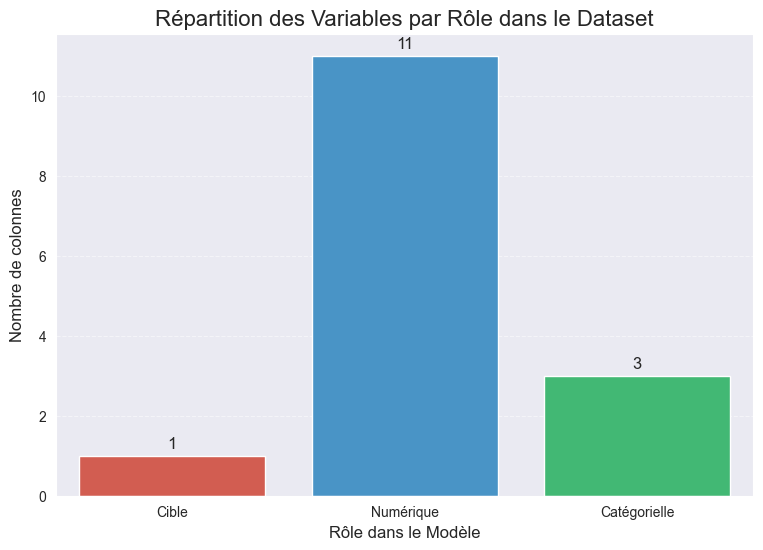

In [49]:
# --- 1. CLASSIFICATION MANUELLE DES COLONNES ---
# Basée sur la structure standard du fichier Hotel_Booking.csv
COLONNE_CIBLE = 'booking_status'

# Colonnes Catégorielles (Nominales) qui nécessitent un One-Hot Encoding
colonnes_categoriques = [
    'type_of_meal_plan',
    'room_type_reserved',
    'market_segment_type'
]

# Colonnes Numériques (inclut les entiers, floats, et les binaires 0/1)
# Nous retirons 'Booking_ID' car elle n'est pas informative
colonnes_numeriques = [
    'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
    'no_of_week_nights', 'lead_time', 'avg_price_per_room',
    'arrival_year', 'arrival_month', 'arrival_date',
    'repeated_guest', 'required_car_parking_space'
]

# 2. CRÉATION DU DATAFRAME DE SYNTHÈSE
data = {
    'Type de Rôle': ['Cible', 'Numérique', 'Catégorielle'],
    'Nombre de Colonnes': [
        1,
        len(colonnes_numeriques),
        len(colonnes_categoriques)
    ]
}
df_classification = pd.DataFrame(data)


# 3. CRÉATION DU GRAPHIQUE À BARRES AVEC SEABORN
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x='Type de Rôle',
    y='Nombre de Colonnes',
    data=df_classification,
    # Utilisation d'une palette de couleurs claire
    palette=['#e74c3c', '#3498db', '#2ecc71']
)

# Ajout des annotations (nombre de colonnes) sur chaque barre
for i in ax.containers:
    ax.bar_label(i, fmt='%d', label_type='edge', padding=3, fontsize=12)

# Personnalisation du graphique
plt.title("Répartition des Variables par Rôle dans le Dataset", fontsize=16)
plt.ylabel("Nombre de colonnes", fontsize=12)
plt.xlabel("Rôle dans le Modèle", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Combien de données ?

In [50]:
print("Nombre de données : ", len(df))

Nombre de données :  29999


## Combien de classes ?

In [51]:
classes_uniques = df['booking_status'].unique()
print(f"Les classes uniques (valeurs) de 'booking_status' sont : {classes_uniques}")

Les classes uniques (valeurs) de 'booking_status' sont : ['Not_Canceled' 'Canceled']


## Quelle répartition entre les classes ?

In [52]:
repartition_classes = df['booking_status'].value_counts()
print("Répartition des classes dans 'booking_status' :\n", repartition_classes)

Répartition des classes dans 'booking_status' :
 booking_status
Not_Canceled    20210
Canceled         9789
Name: count, dtype: int64


## Valeurs manquantes ?

In [53]:
# Vérification du nombre de valeurs manquantes par colonne
missing_values = df.isna().sum()

print("Valeurs manquantes par colonne :")
print(missing_values)

Valeurs manquantes par colonne :
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


## Valeur aberrantes ( Outliers ) ?

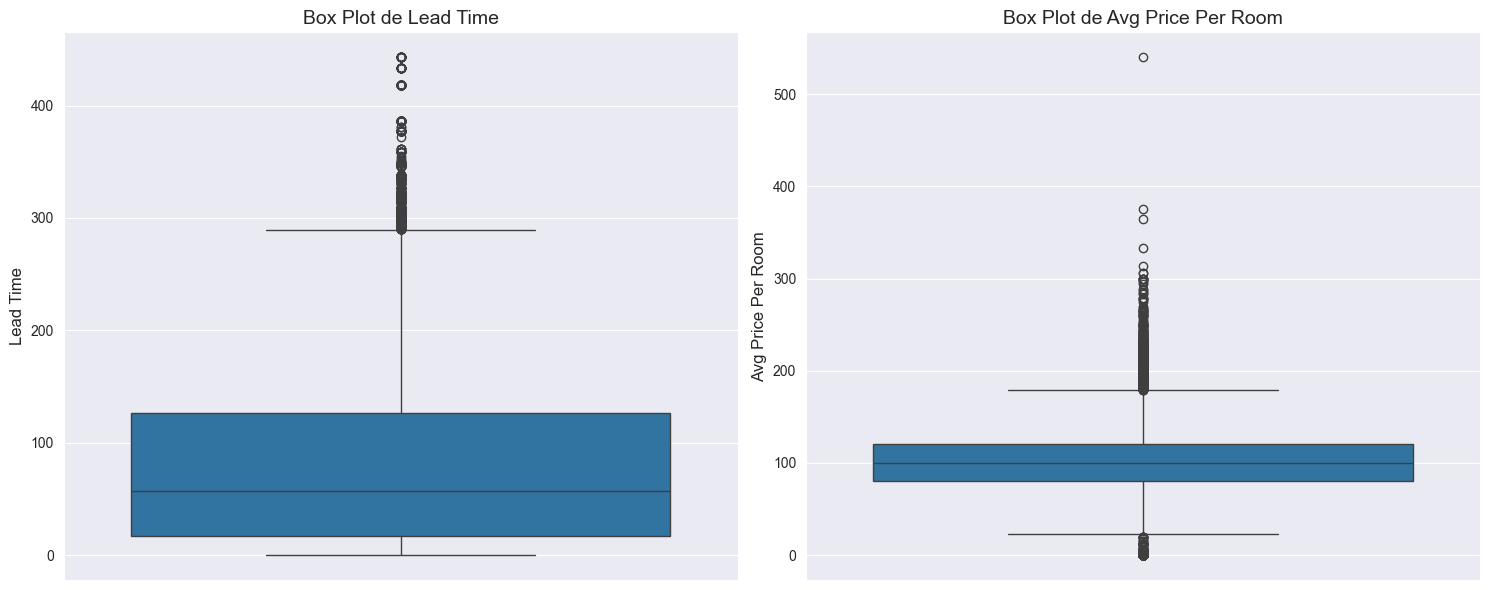

In [54]:
# 2. Définir les variables clés
variables_cles = ['lead_time', 'avg_price_per_room']

# 3. Créer les Box Plots
plt.figure(figsize=(15, 6))

for i, col in enumerate(variables_cles):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot de {col.replace("_", " ").title()}', fontsize=14)
    plt.ylabel(col.replace("_", " ").title(), fontsize=12)

plt.tight_layout()
plt.show()

## Quelle répartition des valeurs sur chaque attribut ?


--- Statistiques Descriptives des Variables Numériques ---
                        count         mean        std     min      25%  \
no_of_adults          29999.0     1.843295   0.519065     0.0     2.00   
no_of_children        29999.0     0.105137   0.401527     0.0     0.00   
no_of_weekend_nights  29999.0     0.812660   0.870109     0.0     0.00   
no_of_week_nights     29999.0     2.201307   1.411846     0.0     1.00   
lead_time             29999.0    85.194740  85.949683     0.0    17.00   
avg_price_per_room    29999.0   103.496161  35.012418     0.0    80.75   
arrival_year          29999.0  2017.820527   0.383754  2017.0  2018.00   
arrival_month         29999.0     7.418747   3.066836     1.0     5.00   
arrival_date          29999.0    15.595920   8.739681     1.0     8.00   

                         50%      75%     max  
no_of_adults             2.0     2.00     4.0  
no_of_children           0.0     0.00    10.0  
no_of_weekend_nights     1.0     2.00     6.0  
no_of_we

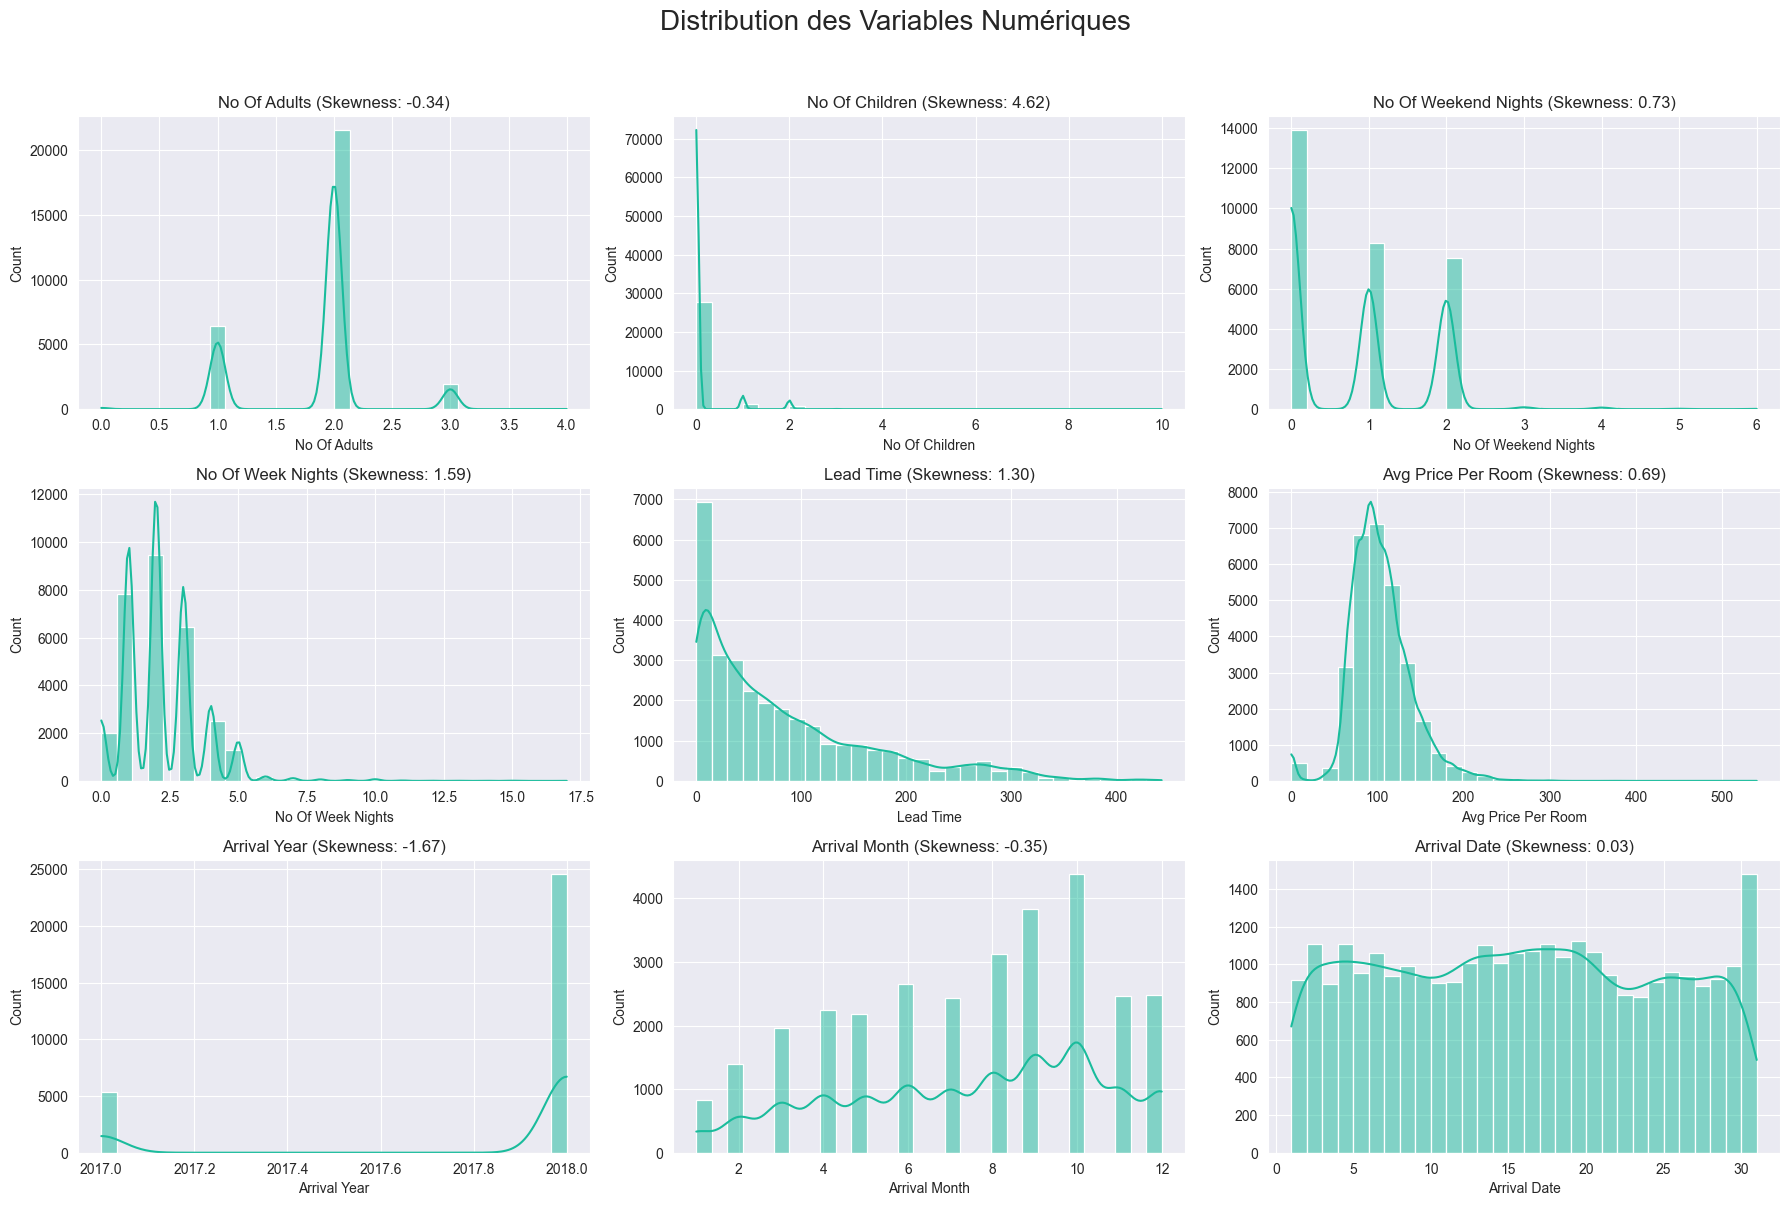

In [55]:
# 1. Sélectionner les colonnes numériques
# (Reprise de la liste utilisée précédemment, en excluant les colonnes catégorielles)
colonnes_numeriques = [
    'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
    'no_of_week_nights', 'lead_time', 'avg_price_per_room',
    'arrival_year', 'arrival_month', 'arrival_date'
]

# 2. Calculer les statistiques descriptives
print("--- Statistiques Descriptives des Variables Numériques ---")
print(df[colonnes_numeriques].describe().T)

# 3. Visualisation des distributions (Histogrammes)
plt.figure(figsize=(18, 15))
plt.suptitle('Distribution des Variables Numériques', fontsize=20, y=1.02)

for i, col in enumerate(colonnes_numeriques):
    plt.subplot(4, 3, i + 1)
    # Utilisez 'kde=True' pour tracer une estimation de la densité (courbe)
    sns.histplot(df[col], kde=True, bins=30, color='#1abc9c')

    # Calculer l'asymétrie (skewness) pour la légende
    skewness = df[col].skew()
    plt.title(f'{col.replace("_", " ").title()} (Skewness: {skewness:.2f})', fontsize=12)
    plt.xlabel(col.replace("_", " ").title(), fontsize=10)

plt.tight_layout()
plt.show()

--- Comptage des Occurrences Uniques ---

Distribution de la colonne : type_of_meal_plan
type_of_meal_plan
Meal Plan 1     23056
Not Selected     4206
Meal Plan 2      2733
Meal Plan 3         4
Name: count, dtype: int64
------------------------------

Distribution de la colonne : market_segment_type
market_segment_type
Online           19182
Offline           8715
Corporate         1685
Complementary      310
Aviation           107
Name: count, dtype: int64
------------------------------


C:\Users\adjenid2025\AppData\Local\Temp\ipykernel_13848\3880304231.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\adjenid2025\AppData\Local\Temp\ipykernel_13848\3880304231.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


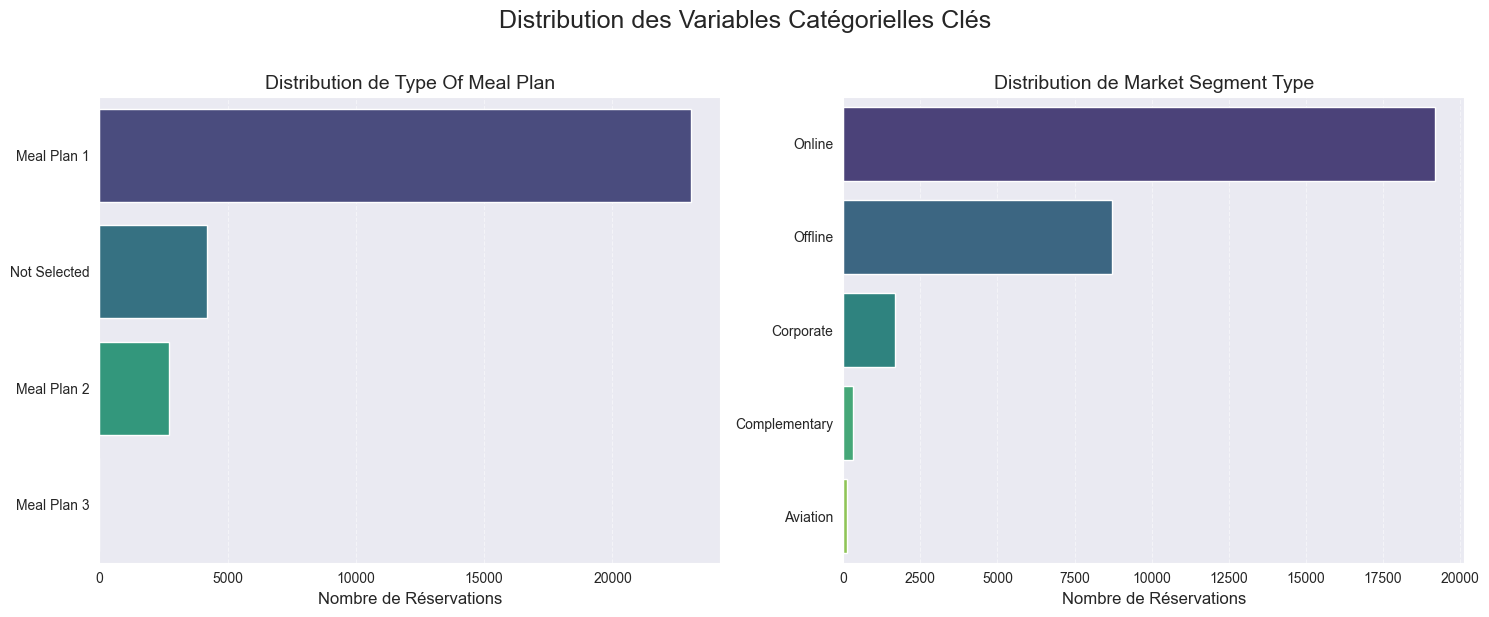

In [56]:
# 1. Définir les variables catégorielles clés à analyser
colonnes_cles_cat = ['type_of_meal_plan', 'market_segment_type']

# 2. Affichage des comptages uniques (value_counts)
print("--- Comptage des Occurrences Uniques ---")
for col in colonnes_cles_cat:
    print(f"\nDistribution de la colonne : {col}")
    print(df[col].value_counts())
    print("-" * 30)

# 3. Visualisation des distributions (Diagrammes à Barres)
plt.figure(figsize=(15, 6))
plt.suptitle('Distribution des Variables Catégorielles Clés', fontsize=18, y=1.02)

for i, col in enumerate(colonnes_cles_cat):
    plt.subplot(1, 2, i + 1)

    # Créer le diagramme à barres
    sns.countplot(
        data=df,
        y=col,  # Utilisation de 'y' pour une meilleure lisibilité des noms longs
        order=df[col].value_counts().index, # Ordonner par fréquence décroissante
        palette='viridis'
    )

    plt.title(f'Distribution de {col.replace("_", " ").title()}', fontsize=14)
    plt.xlabel("Nombre de Réservations", fontsize=12)
    plt.ylabel("") # On laisse l'étiquette sur les barres
    plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- La grande majorité des réservations sont pour deux adultes.
- 75% des réservations n'incluent aucun enfant. Le maximum de 10 est une valeur extrême (outlier) qui pourrait nécessiter une vérification.
- Les séjours sont relativement courts le week-end (75% des cas ont 2 nuits ou moins)
- Les nuitées en semaine sont plus nombreuses que celles du week-end (Moyenne approx 2.2 vs 0.81).

## Quelle caractérisation de chaque attribut ?

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            29999 non-null  object 
 1   no_of_adults                          29999 non-null  int64  
 2   no_of_children                        29999 non-null  int64  
 3   no_of_weekend_nights                  29999 non-null  int64  
 4   no_of_week_nights                     29999 non-null  int64  
 5   type_of_meal_plan                     29999 non-null  object 
 6   required_car_parking_space            29999 non-null  int64  
 7   room_type_reserved                    29999 non-null  object 
 8   lead_time                             29999 non-null  int64  
 9   arrival_year                          29999 non-null  int64  
 10  arrival_month                         29999 non-null  int64  
 11  arrival_date   

## Corrélation entre certains attributs ?

<Axes: >

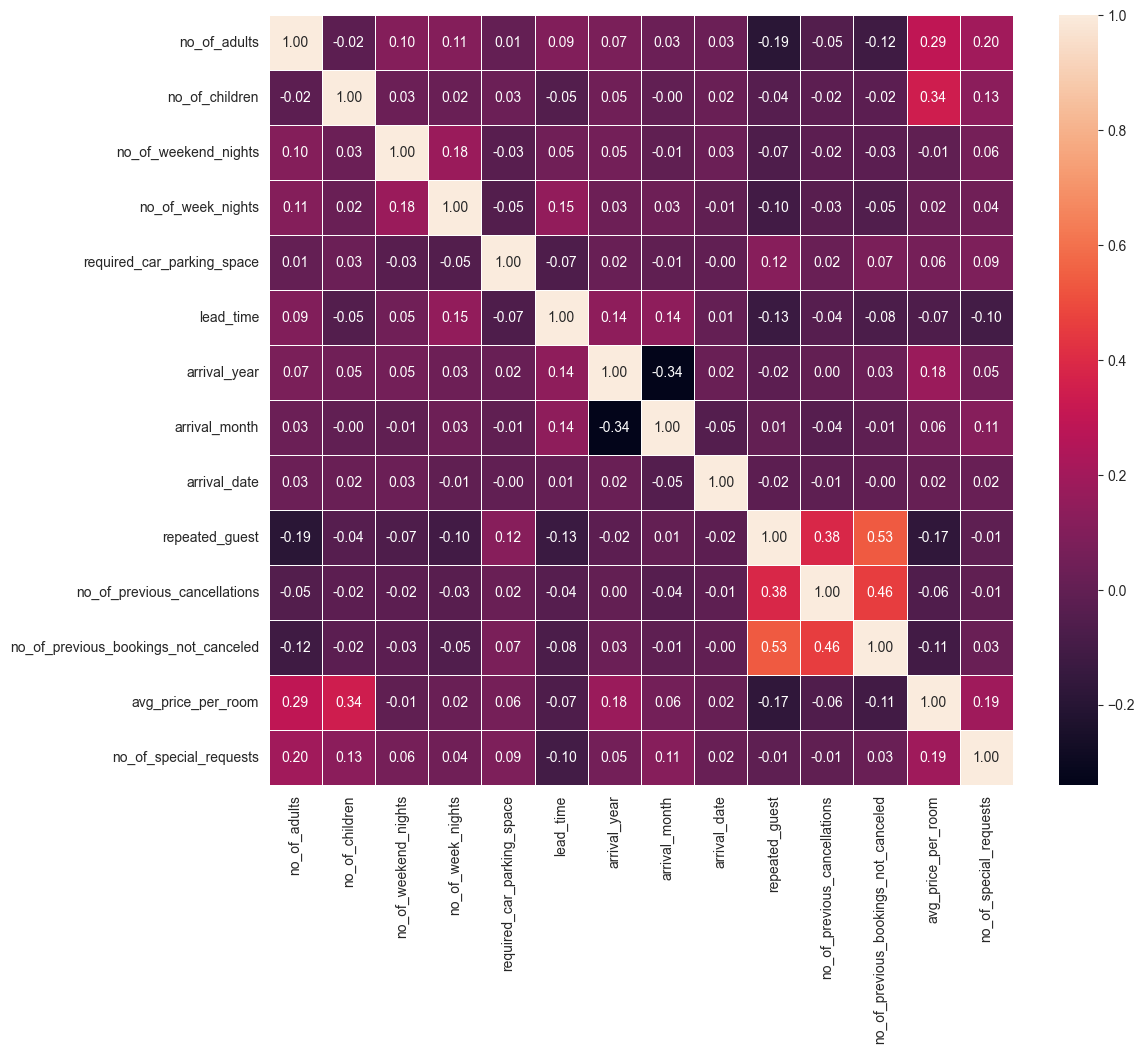

In [58]:
# 1. Sélection des colonnes numériques uniquement
numeric_df = df.select_dtypes(include='number')

# 2. Calcul des corrélations
correlation_matrix = numeric_df.corr()

# 3 Affichage de la heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",linewidths=.5, cbar=True)

## Analyse de la valeur cible

--- Distribution de la Classe Cible (booking_status) ---
booking_status
Not_Canceled    20210
Canceled         9789
Name: count, dtype: int64

Ratio de déséquilibre :
booking_status
Not_Canceled    67.37%
Canceled        32.63%
Name: proportion, dtype: object


C:\Users\adjenid2025\AppData\Local\Temp\ipykernel_13848\1003136661.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution_classes.index, y=distribution_classes.values, palette=['#4CAF50', '#FF5722'])


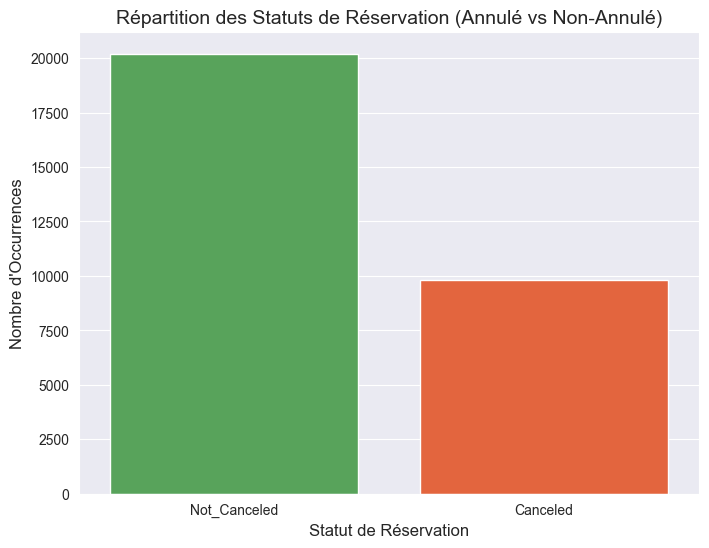

In [59]:
# 1. Compter les occurrences de la classe cible
distribution_classes = df['booking_status'].value_counts()

# 2. Calculer les pourcentages
pourcentage_classes = df['booking_status'].value_counts(normalize=True) * 100

print("--- Distribution de la Classe Cible (booking_status) ---")
print(distribution_classes)
print("\nRatio de déséquilibre :")
print(pourcentage_classes.round(2).astype(str) + '%')

# 3. Visualisation avec un diagramme à barres
plt.figure(figsize=(8, 6))
sns.barplot(x=distribution_classes.index, y=distribution_classes.values, palette=['#4CAF50', '#FF5722'])
plt.title("Répartition des Statuts de Réservation (Annulé vs Non-Annulé)", fontsize=14)
plt.xlabel("Statut de Réservation", fontsize=12)
plt.ylabel("Nombre d'Occurrences", fontsize=12)
plt.show()

Confirmation que l'Accuracy est une métrique trompeuse :Étant donné que la classe majoritaire (Not Canceled) représente près de 67% des données, un modèle naïf qui prédirait toujours "Not Canceled" obtiendrait une précision (Accuracy) de 67%.

- Ce score de $67\%$ est apparemment bon, mais le modèle n'aurait aucune utilité métier, car il ne parviendrait jamais à identifier une seule annulation.
- L'Accuracy ne pénalise pas suffisamment les erreurs sur la classe minoritaire, ce qui masque l'incapacité du modèle à apprendre les annulations.

Conclusion : Nécessité du F1-Score et du Rappel
Pour évaluer la performance de manière pertinente dans ce contexte de données déséquilibrées, les métriques à privilégier sont :

- Rappel (Recall) : Mesure la proportion d'annulations réelles qui ont été correctement identifiées (minimiser les Faux Négatifs). C'est crucial pour l'hôtel qui veut prendre des mesures préventives contre les annulations.

- F1-Score : Offre un équilibre entre le Rappel (Recall) et la Précision (Precision). Il est le meilleur indicateur de performance globale d'un modèle sur un jeu de données déséquilibré, car il ne peut être élevé que si le modèle performe bien sur les deux classes.

## Nettoyage des données nécessaire ?

In [60]:
# Identifier et supprimer les lignes où le prix est égal à zéro
df = df[df['avg_price_per_room'] > 0]

# Supprimer les lignes où il n'y a ni adultes ni enfants (réservations vides)
df = df[ (df['no_of_adults'] + df['no_of_children']) > 0 ]

# Suppression de la colonne redondante
df.drop('no_of_previous_bookings_not_canceled', axis=1, inplace=True)

## Transformation des données ?

In [61]:
# Conversion de types pour l'optimisation
df['no_of_children'] = df['no_of_children'].astype('int64')
df['repeated_guest'] = df['repeated_guest'].astype('category')
df['required_car_parking_space'] = df['required_car_parking_space'].astype('category')

print("\n--- Aperçu du DataFrame après nettoyage ---")
print(f"Nouvelle taille du jeu de données : {df.shape}")
print(df.head())


--- Aperçu du DataFrame après nettoyage ---
Nouvelle taille du jeu de données : (29568, 18)
  Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0  UID_00001             1               0                     1   
1  UID_00002             2               0                     2   
2  UID_00003             2               0                     0   
3  UID_00004             2               0                     2   
4  UID_00005             2               0                     0   

   no_of_week_nights type_of_meal_plan required_car_parking_space  \
0                  0       Meal Plan 1                          1   
1                  5       Meal Plan 1                          0   
2                  1       Meal Plan 1                          0   
3                  0       Meal Plan 2                          0   
4                  2       Meal Plan 2                          0   

  room_type_reserved  lead_time  arrival_year  arrival_month  arrival_date  \
0    

## Encodage

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29568 entries, 0 to 29998
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Booking_ID                    29568 non-null  object  
 1   no_of_adults                  29568 non-null  int64   
 2   no_of_children                29568 non-null  int64   
 3   no_of_weekend_nights          29568 non-null  int64   
 4   no_of_week_nights             29568 non-null  int64   
 5   type_of_meal_plan             29568 non-null  object  
 6   required_car_parking_space    29568 non-null  category
 7   room_type_reserved            29568 non-null  object  
 8   lead_time                     29568 non-null  int64   
 9   arrival_year                  29568 non-null  int64   
 10  arrival_month                 29568 non-null  int64   
 11  arrival_date                  29568 non-null  int64   
 12  market_segment_type           29568 non-null  objec

L'identification unique d'un passager n'est pas pertinent pour la prédiction, donc suppression de cette colonne

In [63]:
df.drop('Booking_ID', axis=1, inplace=True)

Encodage des données categorielle (object) pour utilisation par algorithmes
- type_of_meal_plan
- room_type_reserved
- market_segment_type
- booking_status

In [64]:

# --- 1. Label Encoding pour la variable cible (Booking Status) ---
target_col = 'booking_status'

# Initialiser le LabelEncoder
le = LabelEncoder()

# Appliquer Label Encoding
df[target_col + '_encoded'] = le.fit_transform(df[target_col])

# Afficher les classes et leurs encodages correspondants
print(f"Classes de '{target_col}' et leurs valeurs encodées :")
for i, name in enumerate(le.classes_):
    print(f"  {name}: {i}")

# Supprimer la colonne de statut de réservation d'origine (object)
df = df.drop(columns=[target_col])

# Afficher les premières lignes du DataFrame après encodage
print("\nDataFrame après encodage (premières lignes) :")
print(df.head())

Classes de 'booking_status' et leurs valeurs encodées :
  Canceled: 0
  Not_Canceled: 1

DataFrame après encodage (premières lignes) :
   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0             1               0                     1                  0   
1             2               0                     2                  5   
2             2               0                     0                  1   
3             2               0                     2                  0   
4             2               0                     0                  2   

  type_of_meal_plan required_car_parking_space room_type_reserved  lead_time  \
0       Meal Plan 1                          1        Room_Type 1         37   
1       Meal Plan 1                          0        Room_Type 4        138   
2       Meal Plan 1                          0        Room_Type 1          4   
3       Meal Plan 2                          0        Room_Type 1        386   
4       

Conversion en numerique des données categorielles (Category) pour utilisation algorithme
- required_car_parking_space
- repeated_guest

In [65]:
# Conversion des colonnes 'category' (supposées être 0/1) en int64
colonnes_a_convertir = ['required_car_parking_space', 'repeated_guest']

for col in colonnes_a_convertir:
    # On utilise .astype('int64') pour convertir directement la catégorie en entier
    # Cela fonctionne si les catégories sont déjà 0 et 1.
    df[col] = df[col].astype('int64')

# Afficher les types de données mis à jour pour vérification
print(df[colonnes_a_convertir].info())

<class 'pandas.core.frame.DataFrame'>
Index: 29568 entries, 0 to 29998
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   required_car_parking_space  29568 non-null  int64
 1   repeated_guest              29568 non-null  int64
dtypes: int64(2)
memory usage: 693.0 KB
None


Création d'une colonne de date complète
- arrival_year
- arrival_month
- arrival_date

In [66]:
df['Full_Date'] = pd.to_datetime(df[['arrival_year', 'arrival_month', 'arrival_date']].rename(
    columns={'arrival_year': 'year', 'arrival_month': 'month', 'arrival_date': 'day'}
),errors='coerce')

## Normalisation ? / Ajustement d'échelle

In [68]:
# --- 1. Séparation des variables ---

df.info()
# La variable cible
y = df['booking_status_encoded']

# Les caractéristiques (On retire Booking_ID, la cible, et Full_Date)
X = df.drop(columns=['booking_status_encoded', 'Full_Date'])

# Séparation des jeux d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Définition des sous-ensembles de colonnes ---

# 1. Colonnes numériques à standardiser
numerical_features = [
    'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
    'no_of_week_nights', 'lead_time', 'no_of_previous_cancellations',
    'avg_price_per_room', 'no_of_special_requests'
]

# 2. Colonnes Catégorielles à Encoder (OneHotEncoder)
categorical_features = [
    'type_of_meal_plan', 'room_type_reserved', 'market_segment_type'
]

# 3. Colonnes à laisser telles quelles (binaires/booléennes/date)
# On utilise une liste par compréhension pour s'assurer que seules les colonnes NON traitées
# sont incluses (dans votre cas, c'était le reste, mais nous allons le rendre explicite).
# Assurez-vous d'avoir les colonnes binaires/booléennes ici :
pass_through_features = [
    'repeated_guest', 'required_car_parking_space',
    'arrival_year', 'arrival_month', 'arrival_date' # Colonnes date si traitées comme numériques/ordonnées
]

# --- 3. Construction du ColumnTransformer (CORRIGÉ) ---

preprocessor = ColumnTransformer(
    transformers=[
        # 1. Standardisation (Numérique)
        ('scaler',
         StandardScaler(),
         numerical_features
        ),
        # 2. Encodage One-Hot (Catégoriel)
        ('onehot',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False), # <<< CORRECTION CLÉ ici
         categorical_features
        ),
        # 3. Laisse Passer (Binaire/Date)
        ('passthrough',
         'passthrough',
         pass_through_features
        )
    ],
    remainder='drop'
)

# --- 4. Application de la transformation ---

# Entraînement et transformation sur le jeu d'entraînement
# IMPORTANT: fit_transform() pour X_train
X_train_processed = preprocessor.fit_transform(X_train)

# Transformation sur le jeu de test
# IMPORTANT: transform() pour X_test (utilise les statistiques (moyenne/std) apprises sur X_train)
X_test_processed = preprocessor.transform(X_test)

print("✅ Standardisation complétée avec succès.")
print(f"X_train (avant) : {X_train.shape}")
print(f"X_train (après) : {X_train_processed.shape}\n")

# --- 1. Récupérer la liste complète des noms de colonnes dans l'ordre de traitement ---
# preprocessor est déjà ajusté (fitted) par l'appel précédent à fit_transform(X_train)
colonnes_finales = preprocessor.get_feature_names_out()

# --- 2. Créer le DataFrame avec tous les noms de colonnes ---
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=colonnes_finales
)

print("Aperçu du jeu d'entraînement standardisé (premières colonnes) :")
print(X_train_processed_df.head().to_markdown())

<class 'pandas.core.frame.DataFrame'>
Index: 29568 entries, 0 to 29998
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   no_of_adults                  29568 non-null  int64         
 1   no_of_children                29568 non-null  int64         
 2   no_of_weekend_nights          29568 non-null  int64         
 3   no_of_week_nights             29568 non-null  int64         
 4   type_of_meal_plan             29568 non-null  object        
 5   required_car_parking_space    29568 non-null  int64         
 6   room_type_reserved            29568 non-null  object        
 7   lead_time                     29568 non-null  int64         
 8   arrival_year                  29568 non-null  int64         
 9   arrival_month                 29568 non-null  int64         
 10  arrival_date                  29568 non-null  int64         
 11  market_segment_type           295

## Quelle(s) forme(s) d'apprentissage ?

Étant donné que le projet de porte sur la prédiction de l'annulation d'une réservation nous utiliseront l'apprentissage supervisée. Plus spécifiquement, notre tâche relève d'un problème de classification (Canceled OU Not_Cnanceled)

## Quels algorithmes privilégier ?

Algorithme de classification "Random Forest" : Robustesse et Performance. Gère naturellement les relations non linéaires. Très facile à optimiser et moins sujet au sur-apprentissage

In [69]:
# 1. Définition du Pipeline
# simplifie le code, garantit la transformation évite les fuites de données (data leakage) entre l'entraînement et la prédiction.
# Le pipeline inclut le préprocesseur (StandardScaler) puis le modèle
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor), # Votre ColumnTransformer avec StandardScaler
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. Entraînement
# Le pipeline applique automatiquement le fit_transform puis l'entraînement du modèle
pipeline_rf.fit(X_train, y_train)

# 3. Prédiction sur le jeu de test
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1] # Pour calculer l'AUC-ROC

# 4. Évaluation (Exemple : AUC-ROC et F1-Score sont les meilleurs pour les données déséquilibrées)


print("--- Évaluation des Performances ---")
print(f"Accuracy Score (Random Forest): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision Score (Random Forest): {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall Score (Random Forest): {recall_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC Score (Random Forest): {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"F1-Score (Random Forest): {f1_score(y_test, y_pred_rf):.4f}")

--- Évaluation des Performances ---
Accuracy Score (Random Forest): 0.8911
Precision Score (Random Forest): 0.8987
Recall Score (Random Forest): 0.9436
AUC-ROC Score (Random Forest): 0.9447
F1-Score (Random Forest): 0.9206


AUC-ROC Score (0.9455)
- Signification : L'AUC-ROC (Area Under the Receiver Operating Characteristic Curve) est une mesure indépendante du seuil. Elle représente la probabilité que le modèle classe correctement un exemple positif choisi au hasard plus haut qu'un exemple négatif choisi au hasard.

F1-Score (0.9207)
- Signification : Le F1-Score est la moyenne harmonique de la Précision (proportion de vrais positifs parmi les prédictions positives) et du Rappel (proportion de vrais positifs parmi les exemples positifs réels).

## Quelles performances privilégier ?

- F1-Score (F1-Score) : une des meilleures métriques pour les données déséquilibrées car il cherche à maximiser les deux.

- Rappel (Recall) / Sensibilité :  la capacité du modèle à identifier toutes les réservations qui seront effectivement annulées.

- Précision:  la fiabilité du modèle lorsqu'il prédit qu'une réservation sera annulée.

## Comment améliorer les performances initiales ?

Ici, nous améliorons les performances en mettant en place une optimisation des hyperparametres via le GridSearchCV

In [70]:
# 1. Préparation des données (avec stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Définition du Pipeline (utilisé comme estimateur pour GridSearch)
# La pipeline DOIT inclure le préprocesseur (preprocessor) et le modèle (classifier)
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor), # Votre ColumnTransformer avec StandardScaler et OneHotEncoder
    ('classifier', RandomForestClassifier(random_state=42))
])

# 3. Définition de la Grille des Hyperparamètres (avec le préfixe 'classifier__')
param_grid = {
    'classifier__n_estimators': [100, 200, 300],  # Nombre d'arbres
    'classifier__max_depth': [10, 20, None],      # Profondeur maximale
    'classifier__min_samples_split': [5, 10],     # Échantillons minimum pour une division
    'classifier__class_weight': ['balanced']      # Pondération des classes
}
# J'ai légèrement élargi la grille pour donner une meilleure chance de trouver un optimum

# 4. Configuration et Lancement de GridSearchCV
grid_search_opt = GridSearchCV(
    estimator=pipeline_rf,  # Utiliser la PIPELINE comme estimateur !
    param_grid=param_grid,
    scoring='f1_weighted',  # Mettre la métrique à optimiser
    cv=5,
    verbose=3,
    n_jobs=-1
)

# Lancement de l'optimisation
# Le Pipeline (via grid_search) va maintenant appliquer le préprocesseur à X_train pour chaque fit.
grid_search_opt.fit(X_train, y_train)

# --- Affichage des Résultats de la Recherche ---
print("-" * 40)
print("🔎 Résultats de la recherche (Validation Croisée sur X_train) 🔎")
print(f"Meilleurs paramètres trouvés : {grid_search_opt.best_params_}")
print(f"Meilleur F1-Score (weighted) en CV : {grid_search_opt.best_score_:.4f}")
print("-" * 40)

# 5. Évaluation Finale du Meilleur Modèle
best_pipeline = grid_search_opt.best_estimator_

# Prédictions sur le jeu de test (X_test)
# La meilleure pipeline s'occupe de la transformation de X_test automatiquement
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

# Calcul des métriques pour une comparaison directe
print("\n🏆 Évaluation du Modèle Optimisé (sur X_test) 🏆")
print(f"Accuracy Score (Optimized RF): {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision Score (Optimized RF): {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall Score (Optimized RF): {recall_score(y_test, y_pred_best):.4f}")
print(f"AUC-ROC Score (Optimized RF): {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"F1-Score (Optimized RF - Binaire): {f1_score(y_test, y_pred_best):.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------------------------------------
🔎 Résultats de la recherche (Validation Croisée sur X_train) 🔎
Meilleurs paramètres trouvés : {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Meilleur F1-Score (weighted) en CV : 0.8953
----------------------------------------

🏆 Évaluation du Modèle Optimisé (sur X_test) 🏆
Accuracy Score (Optimized RF): 0.8881
Precision Score (Optimized RF): 0.9027
Recall Score (Optimized RF): 0.9333
AUC-ROC Score (Optimized RF): 0.9456
F1-Score (Optimized RF - Binaire): 0.9177


## Comment choisir les paramètres des algorithmes ?

Ici en utilisant GridSearCV, l'algo avec les meilleurs reglages en fonction des résultats nous est directement renvoyé. Plus besoin de chercher quels paramètres ajuster

## Prédiction sur Data_Test.csv

In [74]:

# --- 1. CHARGEMENT ET DÉFINITION DES COLONNES ---

# Charger le fichier de test.
X_final_test = pd.read_csv("Data_Test.csv", sep=';')

# Liste des colonnes de traitement (pour alignement, assumée correcte à ce stade)
colonnes_X_train = [
    'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
    'no_of_week_nights', 'lead_time', 'avg_price_per_room',
    'arrival_year', 'arrival_month', 'arrival_date',
    'type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
    'repeated_guest', 'required_car_parking_space',
    'no_of_previous_cancellations', 'no_of_special_requests'
]

# Stocker les IDs
booking_ids = X_final_test['Booking_ID']
X_final_test = X_final_test.drop('Booking_ID', axis=1)

# Retrait de la colonne non attendue
if 'no_of_previous_bookings_not_canceled' in X_final_test.columns:
    X_final_test = X_final_test.drop('no_of_previous_bookings_not_canceled', axis=1)

# Alignement et Réordonnancement
X_final_test = X_final_test[colonnes_X_train]


# --- 2. PRÉDICTION AVEC LA BEST PIPELINE ---

# Récupération du meilleur modèle (pipeline complet et optimisé par GridSearchCV)
best_pipeline = grid_search_opt.best_estimator_

# Génération des prédictions (résultat est un array de 0 et 1)
predictions_finales_encodes = best_pipeline.predict(X_final_test)


# --- 3. DÉCODAGE DES PRÉDICTIONS (CORRECTION REQUISE) ---

# Définition du mapping inverse (en se basant sur la correspondance 0=Not_Canceled, 1=Canceled)
# Le dictionnaire {0: 'Not_Canceled', 1: 'Canceled'} est l'inverse de l'encodage.
mapping_decode = {0: 'Not_Canceled', 1: 'Canceled'}

# Conversion de l'array NumPy en une Série Pandas pour appliquer le mapping
predictions_decodees = pd.Series(predictions_finales_encodes).map(mapping_decode)


# --- 4. CRÉATION DU FICHIER DE SOUMISSION CSV ---

# Créer le DataFrame de soumission
df_soumission = pd.DataFrame({
    'Is_Canceled': predictions_decodees
})


# Afficher les 5 premières prédictions pour vérification finale
print("\nPrédictions pour soumission (5 premières lignes, format texte) :")
print(df_soumission.head().to_markdown())

# Enregistrement du dataframe au format csv
nom_fichier_final = "D_Aïssa.csv"
df_soumission.to_csv(nom_fichier_final, index=False)

print(f"\n✅ Fichier de soumission créé : {nom_fichier_final}")


Prédictions pour soumission (5 premières lignes, format texte) :
|    | Is_Canceled   |
|---:|:--------------|
|  0 | Canceled      |
|  1 | Canceled      |
|  2 | Not_Canceled  |
|  3 | Canceled      |
|  4 | Canceled      |

✅ Fichier de soumission créé : D_Aïssa.csv


## Quelle valeur ajoutée pourrait apporter vos analyses et votre algorithme aux hôtels ?

## À quels aspects législatifs devriez-vous prendre garde ?

## Votre algorithme pourrait-il être utilisé à mauvais escient ?